In [ ]:
import json, os

kaggle_creds = {
    "username": "supriyaja",
    "key": "KGAT_f3c3bb201be36d4d63d972ac096b12d7"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d /content/deepfake_data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:33<00:00, 119MB/s]



In [ ]:
!rm -rf /content/deepfake_data
!unzip -q -o 140k-real-and-fake-faces.zip -d /content/deepfake_data

In [ ]:
!find /content/deepfake_data -maxdepth 3 -type d

/content/deepfake_data
/content/deepfake_data/real_vs_fake
/content/deepfake_data/real_vs_fake/real-vs-fake
/content/deepfake_data/real_vs_fake/real-vs-fake/valid
/content/deepfake_data/real_vs_fake/real-vs-fake/train
/content/deepfake_data/real_vs_fake/real-vs-fake/test


In [ ]:
import os

base = '/content/deepfake_data/real_vs_fake/real-vs-fake'
for split in ['train', 'valid', 'test']:
    real_count = len(os.listdir(f'{base}/{split}/real'))
    fake_count = len(os.listdir(f'{base}/{split}/fake'))
    print(f"{split}: real={real_count}, fake={fake_count}")

train: real=50000, fake=50000
valid: real=10000, fake=10000
test: real=10000, fake=10000


In [ ]:
import tensorflow as tf

base = '/content/deepfake_data/real_vs_fake/real-vs-fake'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base}/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base}/valid',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base}/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [ ]:
print(train_ds.class_names)

['fake', 'real']


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model

IMG_SIZE = (224, 224)

# Base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False  # freezing for now

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)  # EfficientNet-specific normalization
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/deepfake_checkpoints/phase1_best.keras',
    save_best_only=True,
    monitor='val_auc',
    mode='max'
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/deepfake_checkpoints', exist_ok=True)

Mounted at /content/drive


In [ ]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 223s 62ms/step - accuracy: 0.7050 - auc: 0.7793 - loss: 0.5700 - val_accuracy: 0.7580 - val_auc: 0.8466 - val_loss: 0.5065
Epoch 2/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - accuracy: 0.7606 - auc: 0.8399 - loss: 0.5012 - val_accuracy: 0.7772 - val_auc: 0.8692 - val_loss: 0.4723
Epoch 3/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 173s 55ms/step - accuracy: 0.7739 - auc: 0.8552 - loss: 0.4788 - val_accuracy: 0.7866 - val_auc: 0.8799 - val_loss: 0.4548
Epoch 4/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 157s 50ms/step - accuracy: 0.7829 - auc: 0.8640 - loss: 0.4651 - val_accuracy: 0.7920 - val_auc: 0.8865 - val_loss: 0.4450
Epoch 5/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 202s 50ms/step - accuracy: 0.7866 - auc: 0.8678 - loss: 0.4582 - val_accuracy: 0.7969 - val_auc: 0.8911 - val_loss: 0.4368
Epoch 6/8
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 173s 55ms/step - accuracy: 0.7881 - auc: 0.8701 - loss: 0.4538 - val_accuracy: 0.8008 - val_auc: 0.8946 - val_loss: 0.4303
Epoch 7/8
3125/3

In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/deepfake_checkpoints/phase1_best.keras'))

True


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_3 InputLayer
1 efficientnetb0 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dropout Dropout
4 dense Dense


In [ ]:
base_model = model.get_layer('efficientnetb0')
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,352,241 (5.16 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [ ]:
checkpoint_cb_p2 = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/deepfake_checkpoints/phase2_best.keras',
    save_best_only=True,
    monitor='val_auc',
    mode='max'
)

early_stop_cb_p2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True
)

history_p2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=6,
    callbacks=[checkpoint_cb_p2, early_stop_cb_p2]
)

Epoch 1/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 217s 61ms/step - accuracy: 0.8254 - auc: 0.9054 - loss: 0.3911 - val_accuracy: 0.8803 - val_auc: 0.9556 - val_loss: 0.2886
Epoch 2/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - accuracy: 0.8819 - auc: 0.9525 - loss: 0.2841 - val_accuracy: 0.9113 - val_auc: 0.9748 - val_loss: 0.2225
Epoch 3/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 172s 55ms/step - accuracy: 0.9085 - auc: 0.9700 - loss: 0.2281 - val_accuracy: 0.9286 - val_auc: 0.9834 - val_loss: 0.1817
Epoch 4/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 220s 61ms/step - accuracy: 0.9237 - auc: 0.9785 - loss: 0.1934 - val_accuracy: 0.9396 - val_auc: 0.9881 - val_loss: 0.1563
Epoch 5/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 188s 60ms/step - accuracy: 0.9344 - auc: 0.9836 - loss: 0.1686 - val_accuracy: 0.9485 - val_auc: 0.9910 - val_loss: 0.1340
Epoch 6/6
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 172s 55ms/step - accuracy: 0.9423 - auc: 0.9872 - loss: 0.1492 - val_accuracy: 0.9530 - val_auc: 0.9929 - val_loss: 0.1213


In [ ]:
test_loss, test_accuracy, test_auc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9514 - auc: 0.9926 - loss: 0.1230
Test Accuracy: 0.9514
Test AUC: 0.9926


In [ ]:
model.save('/content/drive/MyDrive/deepfake_checkpoints/deepfake_detector_final.keras')

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds.flatten() > 0.5).astype(int))

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['fake', 'real']))

[[9774  226]
 [ 745 9255]]
              precision    recall  f1-score   support

        fake       0.93      0.98      0.95     10000
        real       0.98      0.93      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



In [ ]:
for layer in base_model.layers[-10:]:
    print(layer.name, layer.output.shape)

block7a_se_squeeze (None, 1152)
block7a_se_reshape (None, 1, 1, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_se_excite (None, 7, 7, 1152)
block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name='top_activation'):

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(img_array)

        x = model.get_layer('global_average_pooling2d')(base_output)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('dense')(x)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()[0][0]

In [ ]:
def display_gradcam(img_path, model, base_model, alpha=0.4):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array.copy())

    heatmap, pred = make_gradcam_heatmap(img_array_preprocessed, model, base_model)

    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (224, 224)).numpy().squeeze()
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]

    superimposed = heatmap_colored * alpha + (img_array[0] / 255.0) * (1 - alpha)

    label = "REAL" if pred > 0.5 else "FAKE"
    confidence = pred if pred > 0.5 else 1 - pred

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_array[0] / 255.0)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(superimposed)
    axes[1].set_title(f"Grad-CAM: {label} ({confidence:.2%})")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return label, confidence

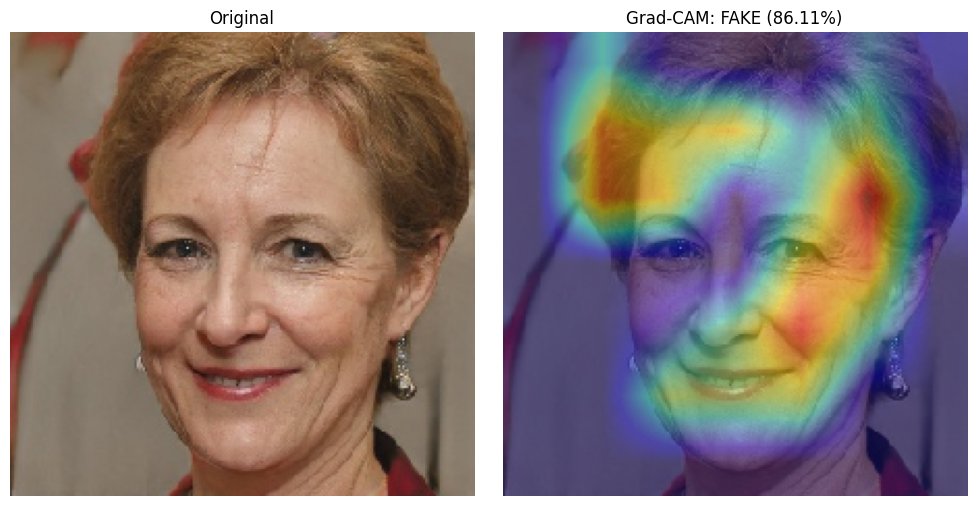

('FAKE', np.float32(0.8611345))

In [ ]:
import os

test_fake_dir = '/content/deepfake_data/real_vs_fake/real-vs-fake/test/fake'
sample_img = os.path.join(test_fake_dir, os.listdir(test_fake_dir)[0])

display_gradcam(sample_img, model, base_model)

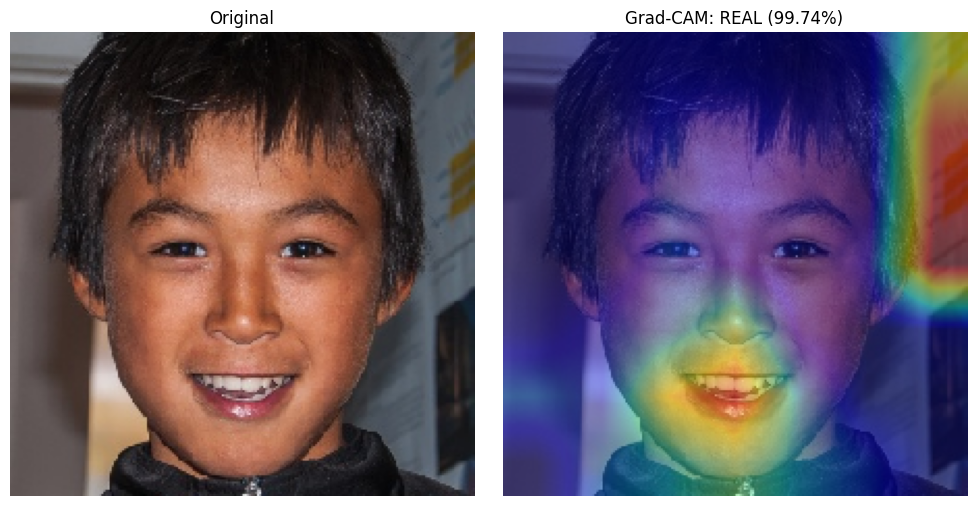

('REAL', np.float32(0.99741))

In [ ]:
test_real_dir = '/content/deepfake_data/real_vs_fake/real-vs-fake/test/real'
sample_real = os.path.join(test_real_dir, os.listdir(test_real_dir)[0])
display_gradcam(sample_real, model, base_model)

In [ ]:
import base64
from io import BytesIO
from PIL import Image

def get_gradcam_base64(img_array_original, heatmap, alpha=0.4):

    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (224, 224)).numpy().squeeze()
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]  # RGB, 0-1 range

    superimposed = heatmap_colored * alpha + (img_array_original / 255.0) * (1 - alpha)
    superimposed = np.clip(superimposed * 255, 0, 255).astype(np.uint8)

    pil_img = Image.fromarray(superimposed)
    buffer = BytesIO()
    pil_img.save(buffer, format='PNG')
    img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')

    return img_base64

In [ ]:
def predict_and_explain(img_path, model, base_model):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array_batch.copy())

    heatmap, pred = make_gradcam_heatmap(img_array_preprocessed, model, base_model)

    label = "real" if pred > 0.5 else "fake"
    confidence = float(pred if pred > 0.5 else 1 - pred)

    gradcam_b64 = get_gradcam_base64(img_array, heatmap)

    return {
        "label": label,
        "confidence": round(confidence, 4),
        "gradcam_image_base64": gradcam_b64
    }

real 0.9974
iVBORw0KGgoAAAANSUhEUgAAAOAAAADgCAIAAACVT/22AAEAAElEQVR4nJT92ZIs2bEliOm0BxvcYzgnJ2QBuAWgq/qh2CIkP4Jv


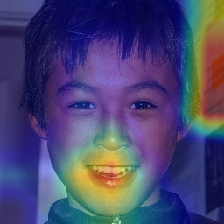

In [ ]:
result = predict_and_explain(sample_real, model, base_model)
print(result['label'], result['confidence'])
print(result['gradcam_image_base64'][:100])


decoded = base64.b64decode(result['gradcam_image_base64'])
Image.open(BytesIO(decoded))

In [ ]:
print(os.path.exists('/content/drive/MyDrive/deepfake_checkpoints/deepfake_detector_final.keras'))

True


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/deepfake_checkpoints/deepfake_detector_final.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>